# L=48 sweep: CPMC with a χ_T=8 DMRG trial, walker bond χ_w = 2, 4, 6

Runs from `run_mps_sweep.py` (`mps_cpmc_new.py`, adaptive plan, 200 walkers, 60 equilibration + 200 sampling blocks of 20 steps, Δτ = 0.01, half filling). Data come from the run folder set below. `results.jsonl` holds the final blocking analysis, `blocks.jsonl` every block (before trot's outlier rejection), and the logs hold the truncation of the reference determinant. Runs still in progress are shown with the blocks logged so far; re-run the notebook to update them. The reference energy is DMRG at χ=200.

In [1]:
RUN = "sweep_L48_T8"          # folder written by run_mps_sweep.py
L = 48
CHI_W = (2, 4, 6)

In [2]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from trot.stat_utils import reject_outliers

RUN = Path(RUN)
COLOR = {2: "#2a78d6", 4: "#eb6834", 6: "#1baf7a"}          # categorical slots 1-3, fixed per chi_w
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})

results = {}
if (RUN / "results.jsonl").exists():
    for line in open(RUN / "results.jsonl"):
        r = json.loads(line)
        results[r["walker_channel_chi"]] = r
blocks = {w: [] for w in CHI_W}
for line in open(RUN / "blocks.jsonl"):
    r = json.loads(line)
    w = int(re.search(r"_w(\d+)_", r["tag"]).group(1))
    if w in blocks:
        blocks[w].append(r)
discarded = {}
for w in CHI_W:
    logs = list(RUN.glob(f"*_w{w}_*.log"))
    found = re.search(r"discarded weights: ([0-9.e+-]+)", logs[0].read_text()) if logs else None
    if found:
        discarded[w] = float(found.group(1))
runs = [w for w in CHI_W if blocks[w]]
if (RUN / "reference.jsonl").exists():          # written by dmrg_reference.py for this run folder
    E_ref = [json.loads(l) for l in open(RUN / "reference.jsonl")][-1]["e_variational"]
else:                                           # the U=4 references of the earlier study
    E_ref = next(json.loads(l)["e_dmrg_chi200"] for l in open("study_dmrg_ref.jsonl") if json.loads(l)["L"] == L)
any_result = next(iter(results.values()), None)
E_trial = any_result["trial_energy"] if any_result else float("nan")
n_eql = any_result["n_equilibration"] if any_result else 60


def status(w):
    rs = blocks[w]
    if w in results and np.isfinite(results[w]["cpmc_energy"]):
        return "done"
    dead = [r["block"] for r in rs if r["weight"] == 0 or not np.isfinite(r["energy"])]
    if dead:
        return f"population collapsed at block {dead[0]}"
    return "done, no finite result" if w in results else f"running ({len(rs)}/260 blocks)"


def alive(w):
    # blocks before a population collapse (weight 0 or non-finite energy)
    out = []
    for r in blocks[w]:
        if r["weight"] == 0 or not np.isfinite(r["energy"]):
            break
        out.append(r)
    return out


print(f"{'chi_w':>5} {'discarded/channel':>18} {'E_CPMC':>12} {'error':>8} {'E - E_ref':>10} {'nodes':>8}  status")
for w in runs:
    r = results.get(w)
    E = r["cpmc_energy"] if r else float("nan")
    err = r["cpmc_error"] if r else float("nan")
    print(f"{w:>5} {discarded.get(w, float('nan')):18.2e} {E:12.5f} {err:8.5f} {E - E_ref:10.5f} "
          f"{blocks[w][-1]['node_encounters']:>8}  {status(w)}")
print(f"DMRG chi=200 reference {E_ref:.5f};  trial (chi_T=8) {E_trial:.5f}")

chi_w  discarded/channel       E_CPMC    error  E - E_ref    nodes  status
    2           8.64e-01          nan      nan        nan   603869  population collapsed at block 96
    4           1.85e-01    -27.12872  0.02922    0.04415     6902  done
    6           1.88e-02    -27.09890  0.00286    0.07397      105  done
DMRG chi=200 reference -27.17287;  trial (chi_T=8) -26.90293


## Energy, truncation and constraint against χ_w

One point per finished run, with the error bar from trot's blocking analysis. Runs without a finite result (a collapsed population, or still running) are left out of the energy panel but kept in the other two.

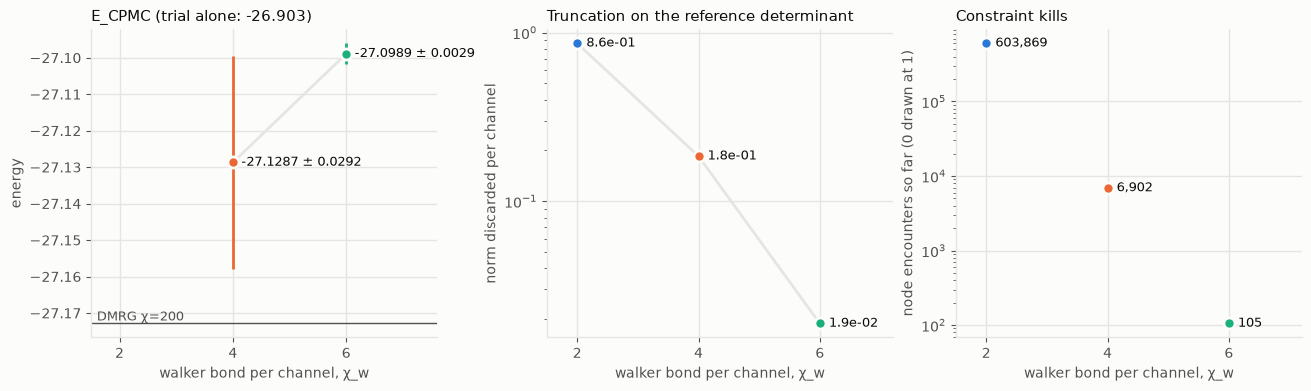

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
done = [w for w in runs if w in results and np.isfinite(results[w]["cpmc_energy"])]

ax = axes[0]
ax.axhline(E_ref, color=INK2, lw=1)
ax.text(1.6, E_ref, "DMRG χ=200", color=INK2, va="bottom", fontsize=9)
if len(done) > 1:
    ax.plot(done, [results[w]["cpmc_energy"] for w in done], color=GRID, lw=2, zorder=1)
for w in done:
    e, s = results[w]["cpmc_energy"], results[w]["cpmc_error"]
    ax.errorbar(w, e, yerr=s, fmt="o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, elinewidth=2, capsize=0, zorder=3)
    ax.text(w + 0.15, e, f"{e:.4f} ± {s:.4f}", color=INK, va="center", fontsize=9)
ax.set_xlim(1.5, 7.6); ax.set_xticks(CHI_W)
ax.set_xlabel("walker bond per channel, χ_w"); ax.set_ylabel("energy")
ax.set_title(f"E_CPMC (trial alone: {E_trial:.3f})", loc="left")

ax = axes[1]
ws = [w for w in runs if w in discarded]
ax.plot(ws, [discarded[w] for w in ws], color=GRID, lw=2, zorder=1)
for w in ws:
    ax.plot(w, discarded[w], "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, discarded[w], f"{discarded[w]:.1e}", color=INK, va="center", fontsize=9)
ax.set_yscale("log"); ax.set_xlim(1.5, 7.2); ax.set_xticks(CHI_W)
ax.set_xlabel("walker bond per channel, χ_w"); ax.set_ylabel("norm discarded per channel")
ax.set_title("Truncation on the reference determinant", loc="left")

ax = axes[2]
for w in runs:
    n = blocks[w][-1]["node_encounters"]
    ax.plot(w, max(n, 1), "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, max(n, 1), f"{n:,}", color=INK, va="center", fontsize=9)
ax.set_yscale("log"); ax.set_xlim(1.5, 7.2); ax.set_xticks(CHI_W)
ax.set_xlabel("walker bond per channel, χ_w"); ax.set_ylabel("node encounters so far (0 drawn at 1)")
ax.set_title("Constraint kills", loc="left")
plt.show()

## Block energies through the run

One panel per run. The thin line is the energy of every block, the thick line the running weighted mean over the sampling blocks that trot's outlier filter keeps, and the shaded band the equilibration phase. The y-range is shared and set by the bulk of the data; blocks outside it are clipped and marked. A collapsed population is drawn up to the collapse only.

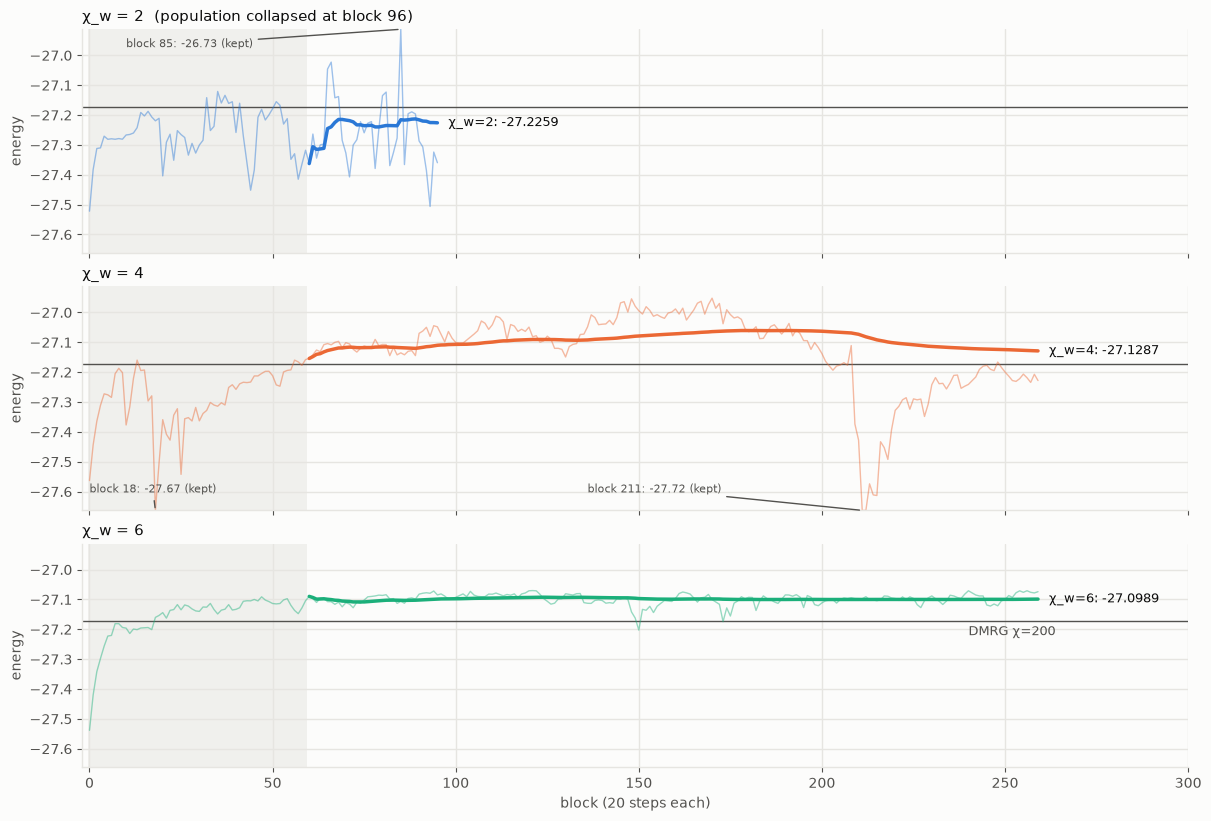

In [4]:
fig, axes = plt.subplots(len(runs), 1, figsize=(12, 2.7 * len(runs)), sharex=True, sharey=True,
                         constrained_layout=True, squeeze=False)
axes = axes[:, 0]
bulk = np.concatenate([[r["energy"] for r in alive(w)] for w in runs])
ylo, yhi = np.percentile(bulk, 0.5) - 0.05, np.percentile(bulk, 99.5) + 0.05
ylo, yhi = min(ylo, E_ref - 0.05), max(yhi, E_ref + 0.05)
for ax, w in zip(axes, runs):
    rs = alive(w)
    b = np.array([r["block"] for r in rs]); e = np.array([r["energy"] for r in rs]); wt = np.array([r["weight"] for r in rs])
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.axhline(E_ref, color=INK2, lw=1)
    ax.plot(b, np.clip(e, ylo, yhi), color=COLOR[w], lw=1, alpha=0.45)
    s = b >= n_eql
    if s.sum() > 1:
        _, keep = reject_outliers(np.column_stack((e[s], wt[s])), obs=0)
        keep = np.asarray(keep)
        rejected = set(b[s][~keep].tolist())
        bs, es, wsum = b[s][keep], e[s][keep], wt[s][keep]
        running = np.cumsum(es * wsum) / np.cumsum(wsum)
        ax.plot(bs, running, color=COLOR[w], lw=2.5)
        ax.text(bs[-1] + 3, running[-1], f"χ_w={w}: {running[-1]:.4f}", color=INK, va="center", fontsize=9)
    else:
        rejected = set()
    clipped = [(bi, ei) for bi, ei in zip(b, e) if ei > yhi or ei < ylo]
    clusters = []                                   # neighbouring clipped blocks share one label
    for bi, ei in clipped:
        if clusters and bi - clusters[-1][-1][0] <= 5:
            clusters[-1].append((bi, ei))
        else:
            clusters.append([(bi, ei)])
    for cluster in clusters:
        bi, ei = max(cluster, key=lambda x: abs(x[1] - E_ref))
        if True:
            edge = yhi if ei > yhi else ylo
            tag = "rejected by trot" if bi in rejected else "kept"
            text_y = yhi - 0.08 * (yhi - ylo) if ei > yhi else ylo + 0.08 * (yhi - ylo)
            ax.annotate(f"block {bi}: {ei:.2f} ({tag})", xy=(bi, edge), xytext=(max(bi - 75, 0), text_y),
                        color=INK2, fontsize=8, arrowprops=dict(arrowstyle="-", color=INK2, lw=1))
    note = status(w)
    ax.set_title(f"χ_w = {w}" + ("" if note == "done" else f"  ({note})"), loc="left")
    ax.set_ylabel("energy")
axes[-1].text(240, E_ref - 0.02 * (yhi - ylo), "DMRG χ=200", color=INK2, va="top", fontsize=9)
axes[-1].set_xlabel("block (20 steps each)")
axes[0].set_ylim(ylo, yhi); axes[0].set_xlim(-2, 300)
plt.show()

## Is the error bar trustworthy? Blocking curve

The sampling blocks are grouped into bins of B consecutive blocks, and the standard error of the weighted mean is recomputed from the bin means. When the blocks are effectively independent at some bin size, the curve reaches a plateau and the error bar can be trusted. A curve that keeps rising means the correlation time is comparable to the run length, and the quoted error is an underestimate.

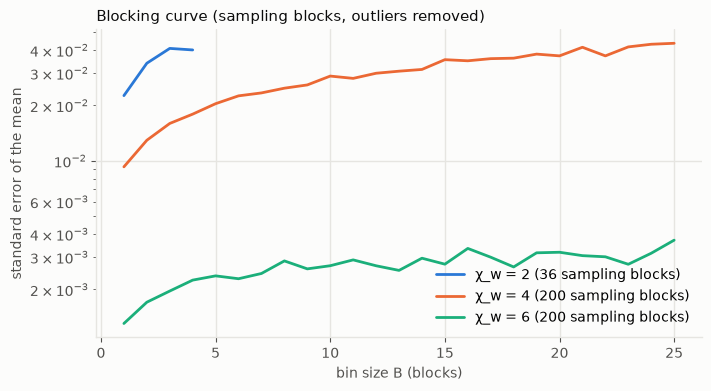

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
for w in runs:
    rs = [r for r in alive(w) if r["block"] >= n_eql]
    if len(rs) < 20:
        continue
    e = np.array([r["energy"] for r in rs]); wt = np.array([r["weight"] for r in rs])
    _, keep = reject_outliers(np.column_stack((e, wt)), obs=0)
    e, wt = e[np.asarray(keep)], wt[np.asarray(keep)]
    sizes = [B for B in range(1, len(e) // 8 + 1)]
    se = []
    for B in sizes:
        k = len(e) // B
        means = [np.sum(e[i * B:(i + 1) * B] * wt[i * B:(i + 1) * B]) / np.sum(wt[i * B:(i + 1) * B]) for i in range(k)]
        se.append(np.std(means, ddof=1) / np.sqrt(k))
    ax.plot(sizes, se, color=COLOR[w], lw=2, label=f"χ_w = {w} ({len(e)} sampling blocks)")
ax.set_yscale("log")
ax.set_xlabel("bin size B (blocks)"); ax.set_ylabel("standard error of the mean")
ax.set_title("Blocking curve (sampling blocks, outliers removed)", loc="left")
ax.legend(loc="lower right")
plt.show()

## Population health

Total walker weight per block (left) and cumulative node encounters (right, log scale).

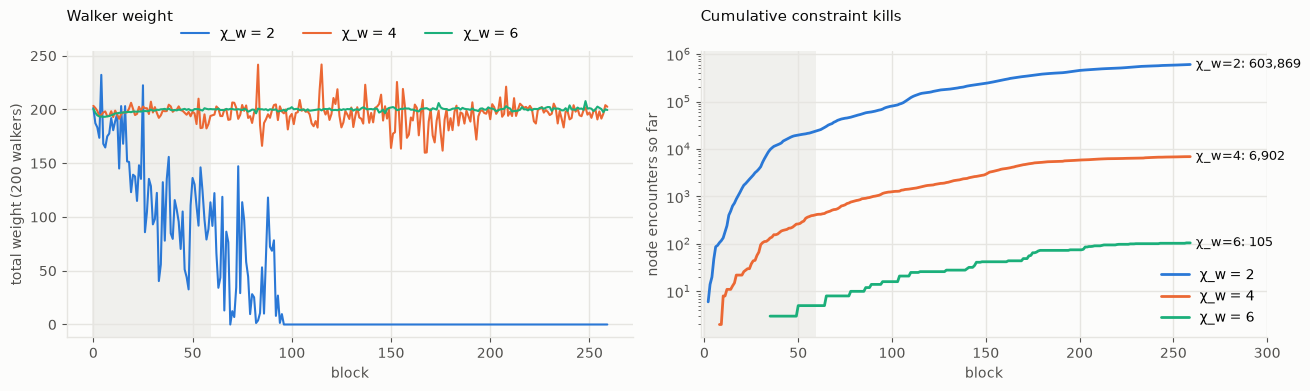

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
for w in runs:
    rs = blocks[w]
    b = np.array([r["block"] for r in rs])
    axes[0].plot(b, [r["weight"] for r in rs], color=COLOR[w], lw=1.5, label=f"χ_w = {w}")
    n = np.array([r["node_encounters"] for r in rs], float)
    if n[-1] > 0:
        axes[1].plot(b, np.where(n > 0, n, np.nan), color=COLOR[w], lw=2, label=f"χ_w = {w}")
        axes[1].text(b[-1] + 3, n[-1], f"χ_w={w}: {int(n[-1]):,}", color=INK, va="center", fontsize=9)
    else:
        axes[1].plot([], [], color=COLOR[w], lw=2, label=f"χ_w = {w} (none)")
for ax in axes:
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.set_xlabel("block")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.13), ncol=3)
axes[1].legend(loc="lower right")
axes[0].set_ylabel("total weight (200 walkers)"); axes[0].set_title("Walker weight", loc="left", pad=22)
axes[1].set_yscale("log"); axes[1].set_xlim(-2, 300)
axes[1].set_ylabel("node encounters so far"); axes[1].set_title("Cumulative constraint kills", loc="left", pad=22)
plt.show()